# Clasificación Supervisada de Textos para Objetivos de Desarrollo Sostenible (ODS)

**Objetivo Principal:** Desarrollar un modelo robusto de machine learning capaz de clasificar textos de participación ciudadana en uno de los 17 Objetivos de Desarrollo Sostenible (ODS) definidos por la ONU.

**Transformación Lógica/Matemática:** 1. Importación de las librerías base para la construcción del espacio vectorial (Bolsa de Palabras), reducción dimensional algebraica (SVD) y modelamiento estadístico subyacente.
2. Fijación estricta de semillas deterministas (`random_state`) en los motores numéricos para garantizar la reproducibilidad innegociable en la partición de datos y convergencia de gradientes.

In [33]:
import os
import re
import warnings
from typing import List, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

In [34]:
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

### Ingesta de Datos y Validación Defensiva

**Transformación Lógica/Matemática:** Carga del archivo binario (`.xlsx`) a una estructura matricial en memoria (DataFrame). Se ejecuta una validación defensiva inmediata sobre la integridad del esquema (nombres de columnas mapeados), las dimensiones espaciales (`.shape`) y la coherencia de tipos. Se audita la presencia de valores nulos o infinitos que provocarían inestabilidad matemática y fallos de dimensionalidad en los tensores de la fase NLP.

In [35]:
def load_and_validate_data(filepath: str, column_mapping: dict = None) -> pd.DataFrame:
    """Carga el dataset Excel y realiza validación defensiva de estructura y columnas."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"[ERROR] Archivo no encontrado en la ruta: {filepath}")

    # Carga de datos
    raw_df = pd.read_excel(filepath)

    # 1. Validación Defensiva de Columnas
    print(f"[INFO] Dataset cargado. Dimensiones exactas (Filas, Columnas): {raw_df.shape}")
    print(f"[INFO] Columnas originales encontradas en el archivo: {raw_df.columns.tolist()}")

    # Renombramiento dinámico para estandarizar el DataFrame
    if column_mapping:
        raw_df = raw_df.rename(columns=column_mapping)
        print(f"[INFO] Columnas tras el mapeo: {raw_df.columns.tolist()}")

    # Validación estricta para prevenir KeyError en etapas posteriores
    required_cols = ['text', 'sdg']
    missing_cols = [col for col in required_cols if col not in raw_df.columns]

    if missing_cols:
        raise KeyError(f"[ERROR CRÍTICO] Faltan las columnas {missing_cols}. "
                       f"Por favor, ajusta el diccionario 'MAPEO_COLUMNAS' con los nombres reales de tu Excel.")

    # 2. Validación de Tipos y Nulos
    print("\n--- Validación de Valores Nulos ---")
    print(raw_df.isnull().sum())

    # Eliminación de posibles nulos críticos para evitar TypeError en TfidfVectorizer
    if raw_df['text'].isnull().any() or raw_df['sdg'].isnull().any():
        print("[WARN] Se detectaron valores nulos. Procediendo a eliminación (dropna).")
        raw_df = raw_df.dropna(subset=['text', 'sdg']).reset_index(drop=True)

    return raw_df

# Ruta actualizada al archivo Excel
DATA_PATH = "./data/dataset.xlsx"

MAPEO_COLUMNAS = {
    'textos': 'text',
    'ODS': 'sdg'
}

# Ejecución de la ingesta
raw_df = load_and_validate_data(DATA_PATH, column_mapping=MAPEO_COLUMNAS)

[INFO] Dataset cargado. Dimensiones exactas (Filas, Columnas): (9656, 2)
[INFO] Columnas originales encontradas en el archivo: ['textos', 'ODS']
[INFO] Columnas tras el mapeo: ['text', 'sdg']

--- Validación de Valores Nulos ---
text    0
sdg     0
dtype: int64


### Análisis Exploratorio de Datos (EDA)

**Transformación Lógica/Matemática:** Extracción de la dimensión escalar de cada documento (conteo de tokens). Generación de distribuciones de frecuencia empíricas para medir la varianza poblacional y cuantificar el desbalance de soporte para las 17 clases (ODS). Esta evaluación geométrica justifica la posterior inclusión de pesos balanceados (`class_weight`) y validación estratificada.

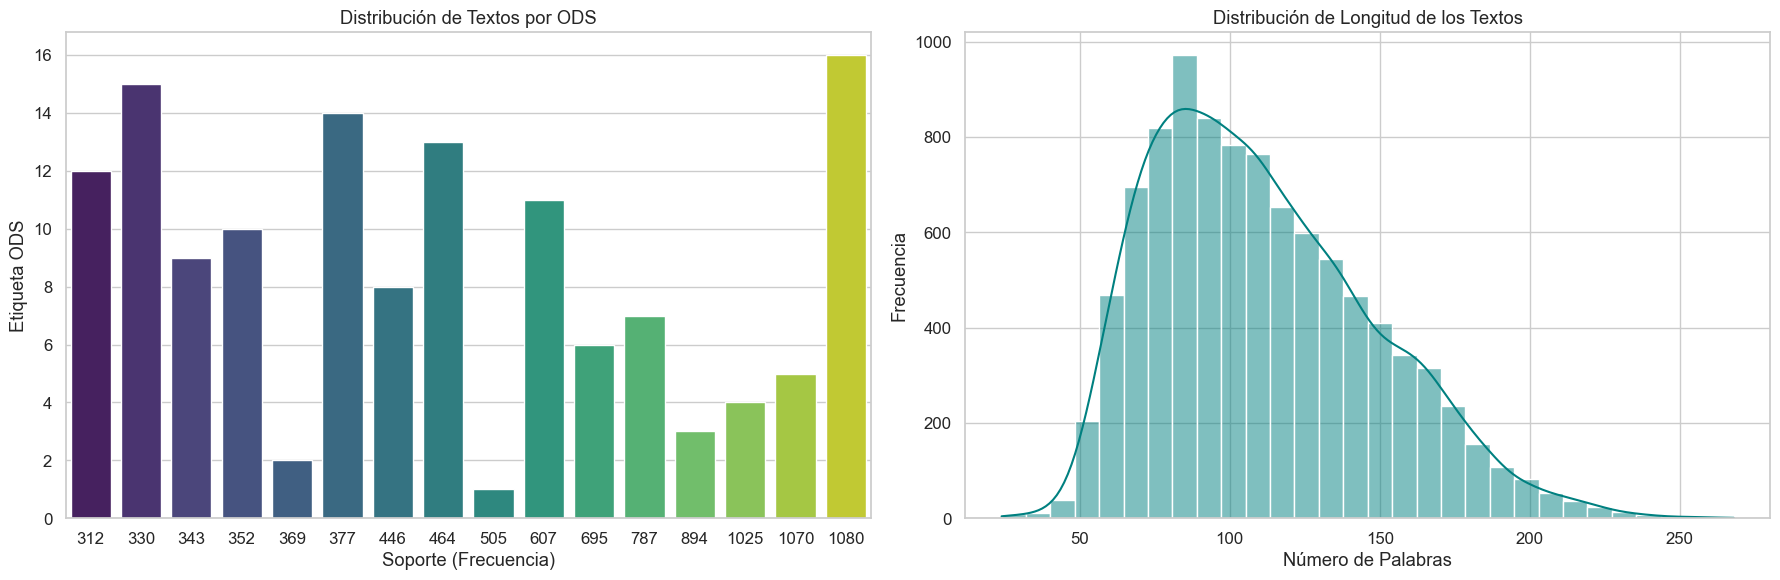

,count,mean,std,min,25%,50%,75%,max
word_count,9656.0,111.017295,37.082212,24.0,82.0,105.0,135.0,268.0


In [36]:
# Cálculo de métrica de longitud
raw_df['word_count'] = raw_df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribución de la variable objetivo
sdg_counts = raw_df['sdg'].value_counts()
sns.barplot(x=sdg_counts.values, y=sdg_counts.index, palette='viridis', ax=axes[0])
axes[0].set_title('Distribución de Textos por ODS')
axes[0].set_xlabel('Soporte (Frecuencia)')
axes[0].set_ylabel('Etiqueta ODS')

# Distribución de dispersión de longitud
sns.histplot(raw_df['word_count'], bins=30, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Distribución de Longitud de los Textos')
axes[1].set_xlabel('Número de Palabras')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

display(raw_df['word_count'].describe().to_frame().T)

### Entrenamiento y Optimización de Hiperparámetros

**Transformación Lógica/Matemática:** Acoplamiento del pipeline de extracción de características a un algoritmo iterativo de Regresión Logística Multinomial. Se implementa una búsqueda estocástica en un espacio hiperparamétrico discreto (`RandomizedSearchCV`). La optimización se guía por validación cruzada estratificada, ajustando el regularizador L2 (parámetro $C$) y la varianza espectral del SVD para maximizar la métrica de castigo Macro F1-Score.

In [37]:
class TextPreprocessor(BaseEstimator, TransformerMixin):
    """
    Limpieza de texto compatible con multiprocessing (Picklable).
    La inicialización de NLTK se difiere al método transform para evitar
    errores de serialización en n_jobs > 1.
    """
    def __init__(self, language: str = 'spanish'):
        self.language = language

    def fit(self, X: pd.Series, y: Optional[pd.Series] = None) -> 'TextPreprocessor':
        return self

    def transform(self, X: pd.Series) -> List[str]:
        # Inicialización diferida dentro del Worker (soluciona BrokenProcessPool)
        import nltk
        from nltk.corpus import stopwords
        from nltk.stem import SnowballStemmer
        import re

        stop_words = set(stopwords.words(self.language))
        stemmer = SnowballStemmer(self.language)

        cleaned_texts = []
        for text in X:
            text = str(text).lower()
            text = re.sub(r'[^a-záéíóúñü]', ' ', text)
            words = [stemmer.stem(w) for w in text.split() if w not in stop_words and len(w) > 2]
            cleaned_texts.append(' '.join(words))

        return cleaned_texts

# Convención de Features y Targets
X = raw_df['text']
y = raw_df['sdg']

# Reproducibilidad y Estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Encapsulamiento secuencial de transformaciones
feature_engineering_pipeline = Pipeline([
    ('cleaner', TextPreprocessor()),
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=3, max_df=0.85)),
    ('svd', TruncatedSVD(n_components=300, random_state=SEED))
])

In [38]:
# Pipeline unificado con clasificador logístico
model_pipeline = Pipeline([
    ('features', feature_engineering_pipeline),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=SEED))
])

# Espacio de búsqueda paramétrica
param_distributions = {
    'features__svd__n_components': [100, 200, 300],
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__class_weight': ['balanced', None]
}

# Validación cruzada optimizando hiperparámetros
search_cv = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

print("[INFO] Iniciando entrenamiento cruzado...")
search_cv.fit(X_train, y_train)

print(f"[SUCCESS] Modelo entrenado. Mejores hiperparámetros:\n{search_cv.best_params_}")

# Asignación con nomenclatura estricta
lr_model = search_cv.best_estimator_

[INFO] Iniciando entrenamiento cruzado...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[SUCCESS] Modelo entrenado. Mejores hiperparámetros:
{'features__svd__n_components': 300, 'classifier__class_weight': 'balanced', 'classifier__C': 1.0}


### Evaluación de Desempeño y Manejo de Entropía

**Transformación Lógica/Matemática:** 1. **Evaluación Estática:** Inferencia vectorial sobre tensores nunca antes vistos ($X_{test}$). Derivación de la matriz de confusión $C$ para ilustrar la dispersión de falsos positivos/negativos, calculando el rendimiento agregado (Precision, Recall, F1-Score).
2. **Inferencia Probabilística (OOD):** Implementación de una función de inferencia libre que extrae el vector de probabilidades de la función *Softmax* subyacente. Si el hiperplano de decisión tiene alta entropía (probabilidad máxima por debajo del umbral de certidumbre), el sistema clasifica la observación como Fuera de Distribución (Out-of-Domain), rechazando clasificaciones forzadas.

REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

           1       0.85      0.80      0.83       101
           2       0.74      0.86      0.80        74
           3       0.94      0.92      0.93       179
           4       0.95      0.94      0.94       205
           5       0.94      0.89      0.91       214
           6       0.95      0.86      0.90       139
           7       0.93      0.87      0.90       158
           8       0.62      0.65      0.64        89
           9       0.62      0.83      0.71        69
          10       0.70      0.66      0.68        70
          11       0.82      0.84      0.83       122
          12       0.77      0.87      0.82        62
          13       0.87      0.88      0.88        93
          14       0.91      0.89      0.90        75
          15       0.89      0.88      0.89        66
          16       0.95      0.95      0.95       216

    accuracy                      

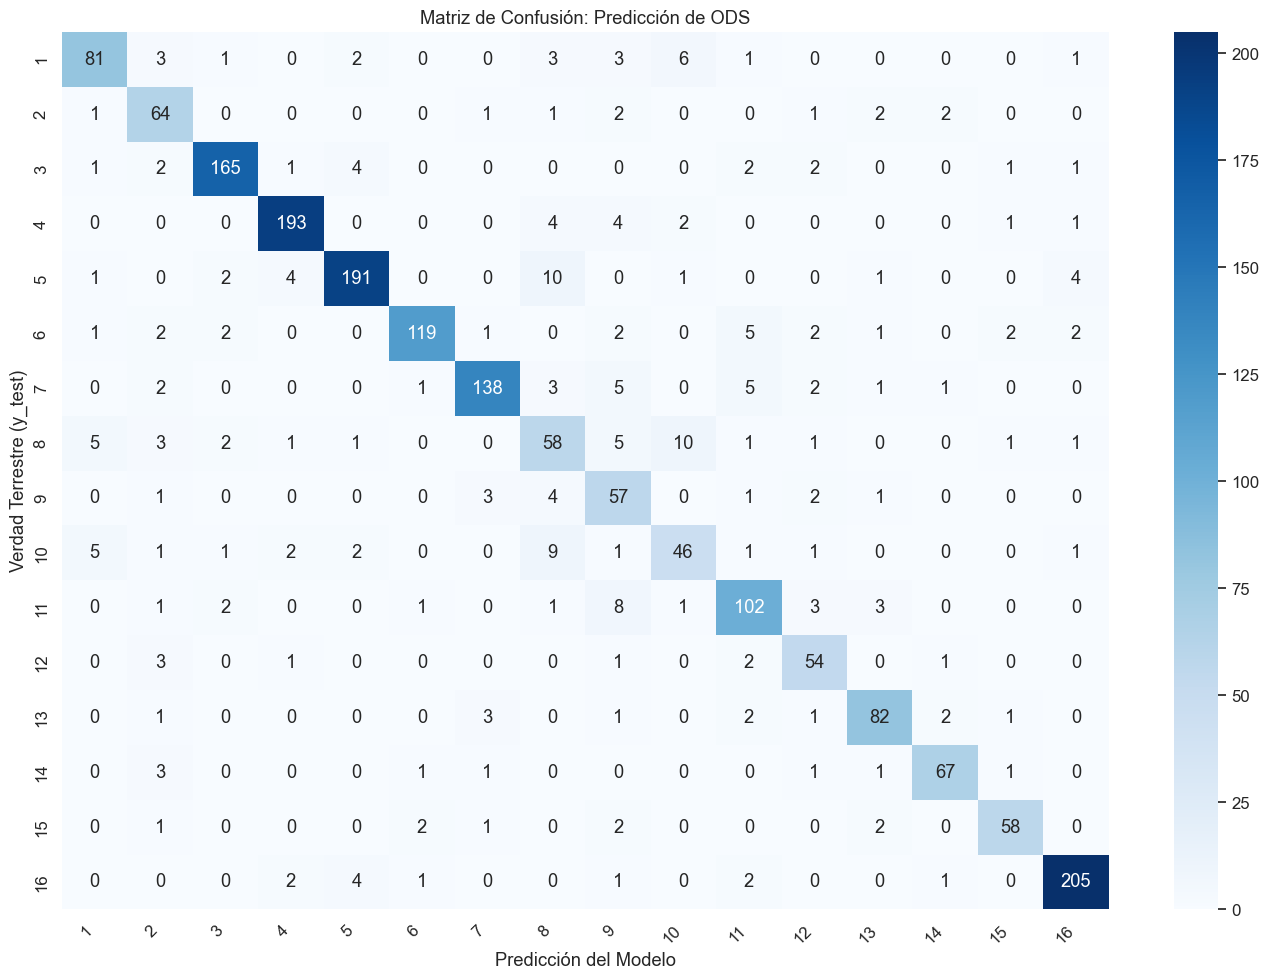

In [39]:
# Predicción sobre el vector de pruebas
y_pred = lr_model.predict(X_test)

# Reporte de clasificación exhaustivo
print("="*60)
print("REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)")
print("="*60)
print(classification_report(y_test, y_pred))

# Generación geométrica de la matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=lr_model.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)
plt.title('Matriz de Confusión: Predicción de ODS')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Verdad Terrestre (y_test)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
import numpy as np
from sklearn.pipeline import Pipeline

def clasificar_texto_ods(texto_crudo: str, modelo_entrenado: Pipeline, umbral_confianza: float = 0.40) -> str:
    """
    Evalúa un texto libre y determina si pertenece a un ODS basado en la
    certidumbre estadística del modelo.

    Args:
        texto_crudo (str): El texto ingresado por el usuario.
        modelo_entrenado (Pipeline): El pipeline unificado (preprocesamiento + clasificador).
        umbral_confianza (float): Probabilidad mínima requerida para aceptar la clasificación.

    Returns:
        str: Cadena de texto con la decisión del sistema.
    """
    # 1. Validación Defensiva Expresa
    if not isinstance(texto_crudo, str) or len(texto_crudo.strip()) < 5:
        raise ValueError("[ERROR] El texto de entrada debe ser un string válido de al menos 5 caracteres.")

    if not hasattr(modelo_entrenado, 'predict_proba'):
        raise TypeError("[ERROR] El clasificador no soporta inferencia probabilística (predict_proba).")

    # 2. Inferencia Computacional
    texto_arr = [texto_crudo]

    # Extraemos el vector de probabilidades
    probabilidades_arr = modelo_entrenado.predict_proba(texto_arr)[0]

    # 3. Análisis de Dimensionalidad y Extracción
    indice_max_prob = np.argmax(probabilidades_arr)
    probabilidad_maxima = probabilidades_arr[indice_max_prob]
    clase_predicha = modelo_entrenado.classes_[indice_max_prob]

    # Corrección: Forzar conversión a string por si las etiquetas son int64
    clase_str = str(clase_predicha)

    # 4. Evaluación de Falla / Detección de Dominio
    if probabilidad_maxima < umbral_confianza:
        return (f"   NO PERTENECE A UN ODS CLARO.\n"
                f"   El modelo presenta demasiada incertidumbre.\n"
                f"   (Aproximación más cercana: {clase_str} con {probabilidad_maxima:.1%} de confianza).")

    return (f"   PERTENECE A UN ODS.\n"
            f"   Clasificación asignada: ODS {clase_str.upper()}\n"
            f"   (Confianza estadística: {probabilidad_maxima:.1%})")


# ==========================================
# CICLO DE EJECUCIÓN Y PRUEBA
# ==========================================

# Prueba 1: Texto dentro del dominio (In-Domain)
texto_valido = "El gobierno debe procurar por hacer popo solo los sabados para ahorrar agua y evitar la contaminación de los ríos."
print("--- PRUEBA 1: TEXTO RELACIONADO CON LA ONU ---")
print(f"Texto: '{texto_valido}'")
print(clasificar_texto_ods(texto_crudo=texto_valido, modelo_entrenado=lr_model, umbral_confianza=0.40))
print("\n" + "="*60 + "\n")

# Prueba 2: Texto fuera del dominio (Out-of-Domain)
texto_invalido = "Millonarios le gano a nacional, lo que provocó un llanto paisa gigantesco, lo que ayudó significativamente en el afluente del rio medellin, ahora ya no se ava a secar, el gobierno deberia procurar hacer que se juegen mas de esos partidos ya que con las lagrimas de los paisas se pueden salvar muchos rios "
print("--- PRUEBA 2: TEXTO COTIDIANO IRRELEVANTE ---")
print(f"Texto: '{texto_invalido}'")
print(clasificar_texto_ods(texto_crudo=texto_invalido, modelo_entrenado=lr_model, umbral_confianza=0.40))

--- PRUEBA 1: TEXTO RELACIONADO CON LA ONU ---
Texto: 'El gobierno debe procurar por hacer popo solo los sabados para ahorrar agua y evitar la contaminación de los ríos.'
   PERTENECE A UN ODS.
   Clasificación asignada: ODS 6
   (Confianza estadística: 85.5%)


--- PRUEBA 2: TEXTO COTIDIANO IRRELEVANTE ---
Texto: 'Millonarios le gano a nacional, lo que provocó un llanto paisa gigantesco, lo que ayudó significativamente en el afluente del rio medellin, ahora ya no se ava a secar, el gobierno deberia procurar hacer que se juegen mas de esos partidos ya que con las lagrimas de los paisas se pueden salvar muchos rios '
   NO PERTENECE A UN ODS CLARO.
   El modelo presenta demasiada incertidumbre.
   (Aproximación más cercana: 6 con 11.8% de confianza).
